In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier


In [2]:
sig_df = pd.read_pickle(Path('./sig_H5pp_m300_features_SR.pkl'))
sig_df["target"] = 1
bkg_df = pd.read_pickle(Path('./bkg_ssWW_EW_features_SR.pkl'))
bkg_df["target"] = 0

In [3]:
combined_df = pd.concat([bkg_df, sig_df], ignore_index=True)
combined_df = combined_df.sample(frac=1).reset_index(drop=True)

In [17]:
for feature in combined_df.columns[:9]:
    roc_score = roc_auc_score(y_true=combined_df["target"], y_score=combined_df[feature])
    print(f"{feature}: {roc_score:.4f}")

jet1_pt_NOSYS: 0.3020
jet2_pt_NOSYS: 0.2902
mjj_NOSYS: 0.5699
dEta_jj_NOSYS: 0.7045
Et_ll_NOSYS: 0.4482
H_t_NOSYS: 0.3309
MT_dilep_NOSYS: 0.4357
pt_ll_NOSYS: 0.4299
mll_NOSYS: 0.4874


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    combined_df.drop(columns=["weight_mc_NOSYS", "target"]),
    combined_df["target"],
    test_size=0.2,
    random_state=42,
)

In [24]:
X_train

,jet1_pt_NOSYS,jet2_pt_NOSYS,mjj_NOSYS,dEta_jj_NOSYS,Et_ll_NOSYS,H_t_NOSYS,MT_dilep_NOSYS,pt_ll_NOSYS,mll_NOSYS
4547,378544.593750,108636.375000,1.750790e+05,0.027793,197053.687500,833791.62500,240247.078125,158957.421875,116458.992188
30506,145460.890625,84957.773438,4.481159e+05,2.649449,111812.734375,659158.87500,142568.796875,25233.705078,108928.179688
37829,87787.742188,61618.378906,1.401240e+06,5.888773,94335.421875,289387.81250,143177.187500,24701.791016,91043.906250
22655,102994.406250,73918.054688,9.381075e+05,4.749529,215958.515625,385821.78125,271786.468750,56149.667969,208531.281250
30862,122298.953125,38983.773438,5.079857e+05,4.017743,105036.476562,294392.43750,192162.468750,15337.375000,103910.664062
...,...,...,...,...,...,...,...,...,...
54343,212225.953125,36037.320312,1.517254e+05,0.040586,237464.953125,748855.62500,205045.140625,167240.531250,168582.953125
38158,211630.781250,168691.656250,3.857699e+05,0.402008,306931.031250,808483.62500,343967.781250,29065.388672,305551.718750
860,157803.875000,128640.437500,7.312704e+04,0.374362,292479.718750,886229.12500,268918.968750,170564.406250,237596.640625
15795,176741.125000,75555.179688,9.657898e+04,0.542599,211579.875000,506509.06250,215993.171875,150816.859375,148392.453125


In [33]:
bdt = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.2,
    max_depth=3,
    random_state=42,
    verbose=1,
)
bdt.fit(X_train, y_train)

      Iter       Train Loss   Remaining Time 
         1           0.6019           25.24s
         2           0.5766           24.17s
         3           0.5580           23.67s
         4           0.5434           23.37s
         5           0.5315           23.06s
         6           0.5227           22.79s
         7           0.5160           22.53s
         8           0.5071           22.26s
         9           0.5019           22.02s
        10           0.4962           21.77s
        20           0.4721           19.36s
        30           0.4627           20.05s
        40           0.4569           16.82s
        50           0.4520           16.07s
        60           0.4491           12.28s
        70           0.4459            8.90s
        80           0.4431            5.77s
        90           0.4402            2.82s
       100           0.4377            0.00s


GradientBoostingClassifier(learning_rate=0.2, random_state=42, verbose=1)

In [35]:
bdt_test_score = bdt.predict_proba(X_test)[:, 1]
print(f"BDT ROC AUC: {roc_auc_score(y_true=y_test, y_score=bdt_test_score):.4f}")

BDT ROC AUC: 0.8596


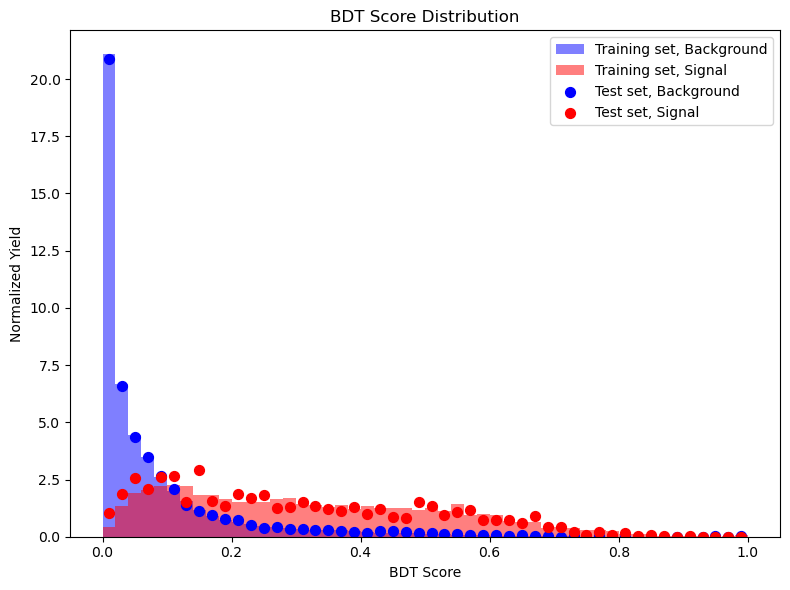

In [39]:
# plot the bdt scores for training and test dataset 

bin_edges = np.linspace(0, 1, 51)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
bdt_train_score = bdt.predict_proba(X_train)[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(
    bdt_train_score[y_train == 0],
    bins=bin_edges,
    alpha=0.5,
    label="Training set, Background",
    color="blue",
    density=True,
)

ax.hist(
    bdt_train_score[y_train == 1],
    bins=bin_edges,
    alpha=0.5,
    label="Training set, Signal",
    color="red",
    density=True,
)

bdt_test_score_hist_yield_bkg, _ = np.histogram(
    bdt_test_score[y_test == 0],
    bins=bin_edges,
    density=True,
)
bdt_test_score_hist_yield_sig, _ = np.histogram(
    bdt_test_score[y_test == 1],
    bins=bin_edges,
    density=True,
)

ax.scatter(
    bin_centers,
    bdt_test_score_hist_yield_bkg,
    label="Test set, Background",
    color="blue",
    marker="o",
    s=50,
)
ax.scatter(
    bin_centers,
    bdt_test_score_hist_yield_sig,
    label="Test set, Signal",
    color="red",
    marker="o",
    s=50,
)

ax.set_xlabel("BDT Score")
ax.set_ylabel("Normalized Yield")
ax.set_title("BDT Score Distribution")
ax.legend()

plt.tight_layout()